# Multi-Factor Portfolio Research Framework — Indian Equities
## Notebook 04 — Walk-Forward Backtest

Takes Notebook 03's portfolio weights (`portfolio_holdings.csv`) and Notebook 01's daily returns and
compounds them into a walk-forward backtest — the first notebook in the project where returns are
computed, rather than only weights or scores. This is the core numbers engine that Notebook 05
(Portfolio Analytics) and Notebook 06 (Regime Diagnostics) build on.

## Objective

Compound Notebook 03's target weights into daily portfolio returns under realistic walk-forward
mechanics — weight drift between rebalances, transaction costs applied at each rebalance — producing
Gross and Net cumulative return series for all six (frequency × weighting scheme) combinations.

## Research Questions Addressed

This notebook produces the return series that Notebook 05 uses to address transaction cost impact and,
together with Notebook 03, rebalancing frequency sensitivity. It does not itself compute risk-adjusted
performance metrics or benchmark comparisons.

## Scope Boundary

This notebook stops at Gross/Net cumulative returns, turnover, and cost drag. Sharpe, Sortino, drawdown
statistics, and benchmark-relative performance are Notebook 05's responsibility.

## Design Decisions (confirmed prior to implementation)

- **Transaction cost formula:** one-way turnover × `DEFAULT_COST_BPS`, where one-way turnover at a
  rebalance is $0.5 \sum |{\text{target weight} - \text{pre-rebalance drifted weight}}|$ across the
  union of previously-held and newly-selected tickers. The buy leg and sell leg are treated as one
  combined cost, not charged separately or doubled — an explicit choice, disclosed here so it is not
  mistaken for the only possible reading of `DEFAULT_COST_BPS` being defined as "per side" in
  `PROJECT_STATE.md`.
- **Gross and Net returns, both reported:** every portfolio variant is reported before costs (Gross)
  and after costs (Net, at `DEFAULT_COST_BPS`), so the cost drag itself is visible rather than only the
  final net number.
- **No benchmark overlay:** this notebook is strictly portfolio-only. NIFTY 50 and Universe Average
  Return comparisons are entirely Notebook 05's role.
- **Walk-forward mechanics:** between rebalance dates, weights are held fixed at the target and allowed
  to drift with daily returns — a real portfolio is not re-weighted every day. At the next rebalance
  date, that day's return is realized using the drifted (pre-rebalance) weights, transaction costs for
  moving into the new target weights are deducted from that same day's return, and the portfolio then
  holds the new target weights going forward.
- **No transaction cost at inception:** the first rebalance date for each frequency has no prior
  portfolio to unwind, so no cost is charged there, and no return is realized on that date itself
  (there is nothing to compound yet). The return series for each portfolio variant begins the first
  trading day after its initial rebalance.
- **Missing daily returns for a held stock** (e.g., a trading halt) are treated as a flat 0% return for
  that stock on that day — disclosed, with the count of such fill events logged per portfolio variant
  as a diagnostic, never silently absorbed.
- **No starting capital, no "portfolio value" language**, per the standing project-wide convention —
  every series is a cumulative return, $\prod_t (1 + r_t)$, and the first plotted value of 1.0 is a
  mathematical normalisation, not invested capital.

## Inputs

- `data/daily_returns.csv` (Notebook 01).
- `data/portfolio_holdings.csv`, `data/study_window.json` (Notebook 03).

## Outputs

- `data/backtest_daily_returns.csv` — daily Gross and Net returns, all six combinations.
- `data/backtest_cumulative_returns.csv` — compounded cumulative return series.
- `data/backtest_turnover_cost_log.csv` — turnover and cost drag at each individual rebalance.
- `data/backtest_diagnostics.csv` — engine sanity-check results.
- `data/backtest_summary.csv` — one-row-per-combination summary.

## Environment Setup

In [1]:
!pip install pandas numpy matplotlib --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\vidya\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


### Configuration: Walk-Forward Backtest Parameters (Locked)

Defines the annualisation factor, the transaction cost basis point convention, the three rebalancing
frequencies and two weighting schemes carried forward from Notebook 03, and the missing-return fill
value. The dark-theme visual configuration is copied verbatim from the preceding notebooks.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
import os
import json

warnings.filterwarnings('ignore')

BASE_DIR   = '.'
DATA_DIR   = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')
os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
#  ▶▶  WALK-FORWARD BACKTEST PARAMETERS (locked)  ◀◀
# ══════════════════════════════════════════════════════════════════════════════
ANN_FACTOR       = 252
RISK_FREE_RATE   = 0.0     # not used in this notebook -- carried forward for NB05 (Sharpe/Sortino)
DEFAULT_COST_BPS = 20      # transaction cost, one-way turnover basis (confirmed convention above)

REBAL_FREQ_STEP = {
    'Monthly':     1,
    'Quarterly':   3,
    'SemiAnnual':  6,
}
WEIGHTING_SCHEMES = ['EqualWeight', 'ERC']

MISSING_RETURN_FILL = 0.0   # a held stock with a missing daily return is treated as flat that day

# -- Visual style: identical to Notebooks 01/02/03, reused across the whole project --
DARK_BG    = '#0D0D0D'
PANEL_BG   = '#1A1A1A'
COLORS     = ['#29B6F6', '#FF7043', '#66BB6A', '#CE93D8', '#FFB300',
              '#F48FB1', '#80DEEA', '#FFCC02', '#A5D6A7', '#EF9A9A']
ACCENT     = '#00FF88'
ACCENT2    = '#FF5252'
GRID_COLOR = '#2A2A2A'
TEXT_COLOR = '#E0E0E0'

plt.rcParams.update({
    'figure.facecolor': DARK_BG,   'axes.facecolor':  DARK_BG,
    'savefig.facecolor': DARK_BG,
    'axes.edgecolor':   GRID_COLOR, 'axes.labelcolor': TEXT_COLOR,
    'xtick.color':      TEXT_COLOR, 'ytick.color':     TEXT_COLOR,
    'text.color':       TEXT_COLOR, 'grid.color':      GRID_COLOR,
    'grid.linestyle':   '--',       'grid.alpha':      0.4,
    'font.family':      'monospace',
    'legend.facecolor': PANEL_BG,  'legend.edgecolor': GRID_COLOR,
})

print('Configuration loaded (Notebook 04 -- Walk-Forward Backtest).')
print(f'  Transaction cost   : {DEFAULT_COST_BPS} bps, one-way turnover basis')
print(f'  Frequencies        : {list(REBAL_FREQ_STEP.keys())}')
print(f'  Weighting schemes  : {WEIGHTING_SCHEMES}')


Configuration loaded (Notebook 04 -- Walk-Forward Backtest).
  Transaction cost   : 20 bps, one-way turnover basis
  Frequencies        : ['Monthly', 'Quarterly', 'SemiAnnual']
  Weighting schemes  : ['EqualWeight', 'ERC']


### Load Notebook 01 and Notebook 03 Outputs

Rebalance dates per frequency are derived directly from `portfolio_holdings.csv` — the single source
of truth for what Notebook 03 actually constructed — rather than re-derived independently from
Notebook 02's monthly grid, avoiding any risk of the two notebooks silently drifting out of sync. A
consistency check confirms both weighting schemes share identical rebalance dates within each
frequency.

In [3]:
daily_returns = pd.read_csv(os.path.join(DATA_DIR, 'daily_returns.csv'), index_col=0, parse_dates=True)
portfolio_holdings = pd.read_csv(
    os.path.join(DATA_DIR, 'portfolio_holdings.csv'), parse_dates=['rebalance_date']
)

with open(os.path.join(DATA_DIR, 'study_window.json'), 'r') as f:
    _sw = json.load(f)
WARMUP_START   = _sw.get('warmup_start',   '2015-07-01')
BACKTEST_START = _sw.get('backtest_start', '2018-07-01')
END_DATE       = _sw.get('end_date',       daily_returns.index[-1].strftime('%Y-%m-%d'))

print(f'Daily returns        : {daily_returns.shape}')
print(f'Portfolio holdings   : {portfolio_holdings.shape}')
print(f'Study window         : backtest {BACKTEST_START} -> {END_DATE}')

# Rebalance dates per frequency, taken directly from what NB03 actually produced
REBAL_DATES_BY_FREQ = {}
for freq_name in REBAL_FREQ_STEP.keys():
    dates = sorted(portfolio_holdings.loc[
        portfolio_holdings['frequency'] == freq_name, 'rebalance_date'
    ].unique())
    REBAL_DATES_BY_FREQ[freq_name] = pd.DatetimeIndex(dates)
    print(f'  {freq_name:12s}: {len(dates):3d} rebalance dates '
          f'({pd.Timestamp(dates[0]).date()} -> {pd.Timestamp(dates[-1]).date()})')

# Sanity check: both weighting schemes must share the exact same rebalance dates per frequency
for freq_name in REBAL_FREQ_STEP.keys():
    for scheme in WEIGHTING_SCHEMES:
        scheme_dates = sorted(portfolio_holdings.loc[
            (portfolio_holdings['frequency'] == freq_name) &
            (portfolio_holdings['weighting_scheme'] == scheme), 'rebalance_date'
        ].unique())
        assert list(scheme_dates) == list(REBAL_DATES_BY_FREQ[freq_name]), (
            f'Rebalance date mismatch between weighting schemes for {freq_name} / {scheme} -- '
            f'this should never happen given how NB03 builds portfolio_holdings.csv.'
        )
print()
print('Rebalance-date consistency check passed: EqualWeight and ERC share identical dates, '
      'per frequency.')


Daily returns        : (2755, 404)
Portfolio holdings   : (5880, 5)
Study window         : backtest 2018-07-01 -> 2026-07-16
  Monthly     :  97 rebalance dates (2018-07-31 -> 2026-07-15)
  Quarterly   :  33 rebalance dates (2018-07-31 -> 2026-07-15)
  SemiAnnual  :  17 rebalance dates (2018-07-31 -> 2026-07-15)

Rebalance-date consistency check passed: EqualWeight and ERC share identical dates, per frequency.


### Build the Target-Weight Lookup

A nested dictionary `TARGET_WEIGHTS[frequency][scheme][rebalance_date] = {ticker: weight}`, built once
from `portfolio_holdings.csv`, so the backtest engine below never has to repeatedly filter the
long-format DataFrame inside its hot loop.

In [4]:
TARGET_WEIGHTS = {}
for freq_name in REBAL_FREQ_STEP.keys():
    TARGET_WEIGHTS[freq_name] = {}
    for scheme in WEIGHTING_SCHEMES:
        TARGET_WEIGHTS[freq_name][scheme] = {}

for (freq_name, scheme, rd), grp in portfolio_holdings.groupby(
    ['frequency', 'weighting_scheme', 'rebalance_date']
):
    TARGET_WEIGHTS[freq_name][scheme][pd.Timestamp(rd)] = dict(zip(grp['ticker'], grp['weight']))

_n_combos = sum(
    len(TARGET_WEIGHTS[f][s]) for f in REBAL_FREQ_STEP for s in WEIGHTING_SCHEMES
)
print(f'Target-weight lookup built: {_n_combos} (frequency, scheme, rebalance_date) entries total.')


Target-weight lookup built: 294 (frequency, scheme, rebalance_date) entries total.


### The Walk-Forward Compounding Engine

The core function of this notebook. For one (frequency, weighting scheme) combination, it:

1. Starts at the first rebalance date with no prior holdings (no cost charged, no return realized that
   day).
2. For each subsequent trading day, computes that day's portfolio return from the previous day's
   weights, then drifts the weights forward using each stock's actual daily return (renormalised so
   weights keep summing to 1 — winners organically grow their portfolio weight between rebalances,
   losers shrink, with no trading involved):
   $$w_i^{(t+1)} = \frac{w_i^{(t)}(1 + r_i^{(t)})}{\sum_j w_j^{(t)}(1 + r_j^{(t)})}$$
3. At each rebalance date, the day's return is realized using the pre-rebalance drifted weights, then a
   transaction cost is deducted from that same day to reflect moving into the new target weights:
   $$\text{turnover} = \tfrac{1}{2}\sum_i \left| w_i^{\text{target}} - w_i^{\text{drifted}} \right|,
   \qquad \text{cost} = \text{turnover} \times \text{DEFAULT\_COST\_BPS}$$
4. After the final rebalance date, weights continue to drift uncorrected through to the end of
   available price history — there is no further rebalance to correct back to target, which mirrors a
   live portfolio that keeps drifting until its next scheduled rebalance.

Returns a dict with `gross_returns`, `net_returns`, `turnover_log`, and a `missing_return_fills`
diagnostic count.

In [5]:
def run_walk_forward_backtest(freq_name, scheme):
    rebal_dates = REBAL_DATES_BY_FREQ[freq_name]
    weights_by_date = TARGET_WEIGHTS[freq_name][scheme]

    # Fixed ticker universe for this combo = every ticker ever held at any rebalance date
    all_tickers = sorted(set().union(*[set(w.keys()) for w in weights_by_date.values()]))
    ticker_pos = {t: i for i, t in enumerate(all_tickers)}
    n_tickers = len(all_tickers)

    raw_panel = daily_returns.reindex(columns=all_tickers)
    missing_mask_full = raw_panel.isna().to_numpy()
    returns_full = raw_panel.fillna(MISSING_RETURN_FILL).to_numpy()
    trading_dates = daily_returns.index
    date_pos = {d: i for i, d in enumerate(trading_dates)}

    gross_returns = {}
    net_returns = {}
    turnover_log = []
    missing_return_fills = 0

    w = np.zeros(n_tickers)   # current (drifted) weight vector
    have_position = False

    for i, rd in enumerate(rebal_dates):
        rd = pd.Timestamp(rd)
        target = weights_by_date[rd]
        target_vec = np.zeros(n_tickers)
        for t, wt in target.items():
            target_vec[ticker_pos[t]] = wt

        if not have_position:
            # Inception: no prior holdings, no cost, no return realized on this date itself.
            w = target_vec.copy()
            have_position = True
            continue

        next_rd = pd.Timestamp(rebal_dates[i + 1]) if i + 1 < len(rebal_dates) else None
        holding_days = trading_dates[
            (trading_dates > pd.Timestamp(rebal_dates[i - 1])) & (trading_dates <= rd)
        ]

        # Drift day-by-day up to (but not including) the rebalance date itself
        for day in holding_days[:-1]:
            pos = date_pos[day]
            r = returns_full[pos]
            held_mask = w > 1e-12
            missing_return_fills += int(np.sum(missing_mask_full[pos] & held_mask))

            day_ret = float(np.dot(w, r))
            gross_returns[day] = day_ret
            net_returns[day] = day_ret   # no cost on non-rebalance days

            w = w * (1.0 + r)
            w_sum = w.sum()
            if w_sum > 0:
                w = w / w_sum

        # Rebalance date itself: realize the return using pre-rebalance drifted weights
        pos = date_pos[rd]
        r = returns_full[pos]
        held_mask = w > 1e-12
        missing_return_fills += int(np.sum(missing_mask_full[pos] & held_mask))

        gross_ret_rd = float(np.dot(w, r))
        w_drifted = w * (1.0 + r)
        w_drifted_sum = w_drifted.sum()
        if w_drifted_sum > 0:
            w_drifted = w_drifted / w_drifted_sum

        turnover = 0.5 * np.sum(np.abs(target_vec - w_drifted))
        cost_fraction = turnover * (DEFAULT_COST_BPS / 10000.0)

        gross_returns[rd] = gross_ret_rd
        net_returns[rd] = gross_ret_rd - cost_fraction

        turnover_log.append({
            'frequency': freq_name, 'weighting_scheme': scheme, 'rebalance_date': rd,
            'turnover_pct': turnover * 100.0, 'cost_drag_bps': cost_fraction * 10000.0,
        })

        w = target_vec.copy()   # reset to new target for the next holding period

    # Drift through to the end of available price history after the final rebalance
    last_rd = pd.Timestamp(rebal_dates[-1])
    tail_days = trading_dates[trading_dates > last_rd]
    for day in tail_days:
        pos = date_pos[day]
        r = returns_full[pos]
        held_mask = w > 1e-12
        missing_return_fills += int(np.sum(missing_mask_full[pos] & held_mask))

        day_ret = float(np.dot(w, r))
        gross_returns[day] = day_ret
        net_returns[day] = day_ret

        w = w * (1.0 + r)
        w_sum = w.sum()
        if w_sum > 0:
            w = w / w_sum

    gross_series = pd.Series(gross_returns).sort_index()
    net_series = pd.Series(net_returns).sort_index()

    return {
        'gross_returns': gross_series,
        'net_returns': net_series,
        'turnover_log': turnover_log,
        'missing_return_fills': missing_return_fills,
    }


print('Walk-forward compounding engine defined.')


Walk-forward compounding engine defined.


### Run the Backtest Across All 6 (Frequency × Weighting Scheme) Combinations

In [6]:
BACKTEST_RESULTS = {}
all_turnover_rows = []
daily_return_rows = []

for freq_name in REBAL_FREQ_STEP.keys():
    for scheme in WEIGHTING_SCHEMES:
        result = run_walk_forward_backtest(freq_name, scheme)
        BACKTEST_RESULTS[(freq_name, scheme)] = result
        all_turnover_rows.extend(result['turnover_log'])

        combo_df = pd.DataFrame({
            'gross_return': result['gross_returns'],
            'net_return': result['net_returns'],
        })
        combo_df['frequency'] = freq_name
        combo_df['weighting_scheme'] = scheme
        combo_df.index.name = 'date'
        daily_return_rows.append(combo_df.reset_index())

        print(f'{freq_name:12s} / {scheme:12s}: {len(result["gross_returns"]):4d} return days, '
              f'{len(result["turnover_log"]):3d} rebalances, '
              f'{result["missing_return_fills"]:4d} missing-return fills')

backtest_daily_returns = pd.concat(daily_return_rows, ignore_index=True)
turnover_cost_log = pd.DataFrame(all_turnover_rows)

print()
print(f'Total backtest daily-return rows: {len(backtest_daily_returns)}')
print(f'Total turnover/cost log entries : {len(turnover_cost_log)}')


Monthly      / EqualWeight : 1964 return days,  96 rebalances,    0 missing-return fills
Monthly      / ERC         : 1964 return days,  96 rebalances,    0 missing-return fills
Quarterly    / EqualWeight : 1964 return days,  32 rebalances,    0 missing-return fills
Quarterly    / ERC         : 1964 return days,  32 rebalances,    0 missing-return fills
SemiAnnual   / EqualWeight : 1964 return days,  16 rebalances,    0 missing-return fills
SemiAnnual   / ERC         : 1964 return days,  16 rebalances,    0 missing-return fills

Total backtest daily-return rows: 11784
Total turnover/cost log entries : 288


Every combination produced 1,964 return days with 0 missing-return fills, and rebalance
counts matching Notebook 03 exactly (96/32/16 for Monthly/Quarterly/Semi-Annual respectively, one
fewer than the total rebalance dates since the first carries no realized return).

### Diagnostics: Sanity Checks

Before trusting any of the return numbers, the mechanics of the engine itself are verified: weights
should always sum to approximately 1 after every drift/renormalisation step, return-day coverage should
be contiguous with no unexplained gaps, and missing-return fills should be a small fraction of total
observations rather than a large one — a large fraction would indicate a data problem worth
investigating rather than silently proceeding past.

In [7]:
diagnostic_rows = []
for (freq_name, scheme), result in BACKTEST_RESULTS.items():
    gross = result['gross_returns']
    n_days = len(gross)
    n_rebalances = len(result['turnover_log'])
    n_missing_fills = result['missing_return_fills']

    expected_days = daily_returns.index[
        (daily_returns.index > REBAL_DATES_BY_FREQ[freq_name][0]) &
        (daily_returns.index <= daily_returns.index[-1])
    ]
    coverage_ok = n_days == len(expected_days)

    diagnostic_rows.append({
        'frequency': freq_name, 'weighting_scheme': scheme,
        'n_return_days': n_days, 'n_rebalances': n_rebalances,
        'n_missing_return_fills': n_missing_fills,
        'missing_fill_pct_of_days': round(100.0 * n_missing_fills / max(n_days, 1), 3),
        'date_coverage_matches_expected': coverage_ok,
    })

diagnostics_df = pd.DataFrame(diagnostic_rows)
print(diagnostics_df.to_string(index=False))

n_coverage_issues = (~diagnostics_df['date_coverage_matches_expected']).sum()
if n_coverage_issues > 0:
    print(f'\nWARNING: {n_coverage_issues} combo(s) have unexpected date-coverage gaps -- '
          f'investigate before trusting downstream numbers.')
else:
    print('\nDate coverage OK for all 6 combinations: every trading day after the first rebalance '
          'has a return, with no unexplained gaps.')

high_missing = diagnostics_df[diagnostics_df['missing_fill_pct_of_days'] > 5.0]
if len(high_missing) > 0:
    print(f'\nNOTE: {len(high_missing)} combo(s) have more than 5% of return-days affected by at '
          f'least one missing-return fill -- worth a closer look, though this is a per-stock-day '
          f'count, not a per-day-entirely-missing count.')
else:
    print('Missing-return fills are a small fraction of total observations across all combinations.')


 frequency weighting_scheme  n_return_days  n_rebalances  n_missing_return_fills  missing_fill_pct_of_days  date_coverage_matches_expected
   Monthly      EqualWeight           1964            96                       0                       0.0                            True
   Monthly              ERC           1964            96                       0                       0.0                            True
 Quarterly      EqualWeight           1964            32                       0                       0.0                            True
 Quarterly              ERC           1964            32                       0                       0.0                            True
SemiAnnual      EqualWeight           1964            16                       0                       0.0                            True
SemiAnnual              ERC           1964            16                       0                       0.0                            True

Date coverage OK for all 6

Date coverage matches the expected trading-day count exactly for all six combinations,
with zero missing-return fills — no data-quality caveat applies to the return series produced here.

### Compute Cumulative Returns (Gross and Net)

$$\text{cumulative return}_T = \prod_{t=1}^{T} (1 + r_t)$$

per the project's standing no-starting-capital convention — the first value of every series is exactly
1.0, a mathematical normalisation, never invested capital or "portfolio value.\"

In [8]:
cumulative_rows = []
for (freq_name, scheme), result in BACKTEST_RESULTS.items():
    cum_gross = (1.0 + result['gross_returns']).cumprod()
    cum_net = (1.0 + result['net_returns']).cumprod()
    for date in cum_gross.index:
        cumulative_rows.append({
            'date': date, 'frequency': freq_name, 'weighting_scheme': scheme,
            'cumulative_gross_return': cum_gross.loc[date],
            'cumulative_net_return': cum_net.loc[date],
        })

cumulative_returns_df = pd.DataFrame(cumulative_rows)

print('Final cumulative return (Gross / Net) per combination:')
for (freq_name, scheme), result in BACKTEST_RESULTS.items():
    cum_gross_final = (1.0 + result['gross_returns']).cumprod().iloc[-1]
    cum_net_final = (1.0 + result['net_returns']).cumprod().iloc[-1]
    print(f'  {freq_name:12s} / {scheme:12s}: '
          f'Gross = {cum_gross_final:.4f}  ({(cum_gross_final - 1) * 100:+.2f}%)   '
          f'Net = {cum_net_final:.4f}  ({(cum_net_final - 1) * 100:+.2f}%)')


Final cumulative return (Gross / Net) per combination:
  Monthly      / EqualWeight : Gross = 6.8459  (+584.59%)   Net = 6.4627  (+546.27%)
  Monthly      / ERC         : Gross = 6.6094  (+560.94%)   Net = 6.2329  (+523.29%)
  Quarterly    / EqualWeight : Gross = 7.3105  (+631.05%)   Net = 7.0924  (+609.24%)
  Quarterly    / ERC         : Gross = 7.0864  (+608.64%)   Net = 6.8723  (+587.23%)
  SemiAnnual   / EqualWeight : Gross = 7.3659  (+636.59%)   Net = 7.2165  (+621.65%)
  SemiAnnual   / ERC         : Gross = 7.1036  (+610.36%)   Net = 6.9606  (+596.06%)


### Chart: Cumulative Return, Gross vs. Net, by Frequency and Weighting Scheme

Overlays both weighting schemes' Gross and Net cumulative return paths for each rebalancing frequency,
making the cost drag between Gross and Net visually apparent alongside the frequency and scheme
comparisons.

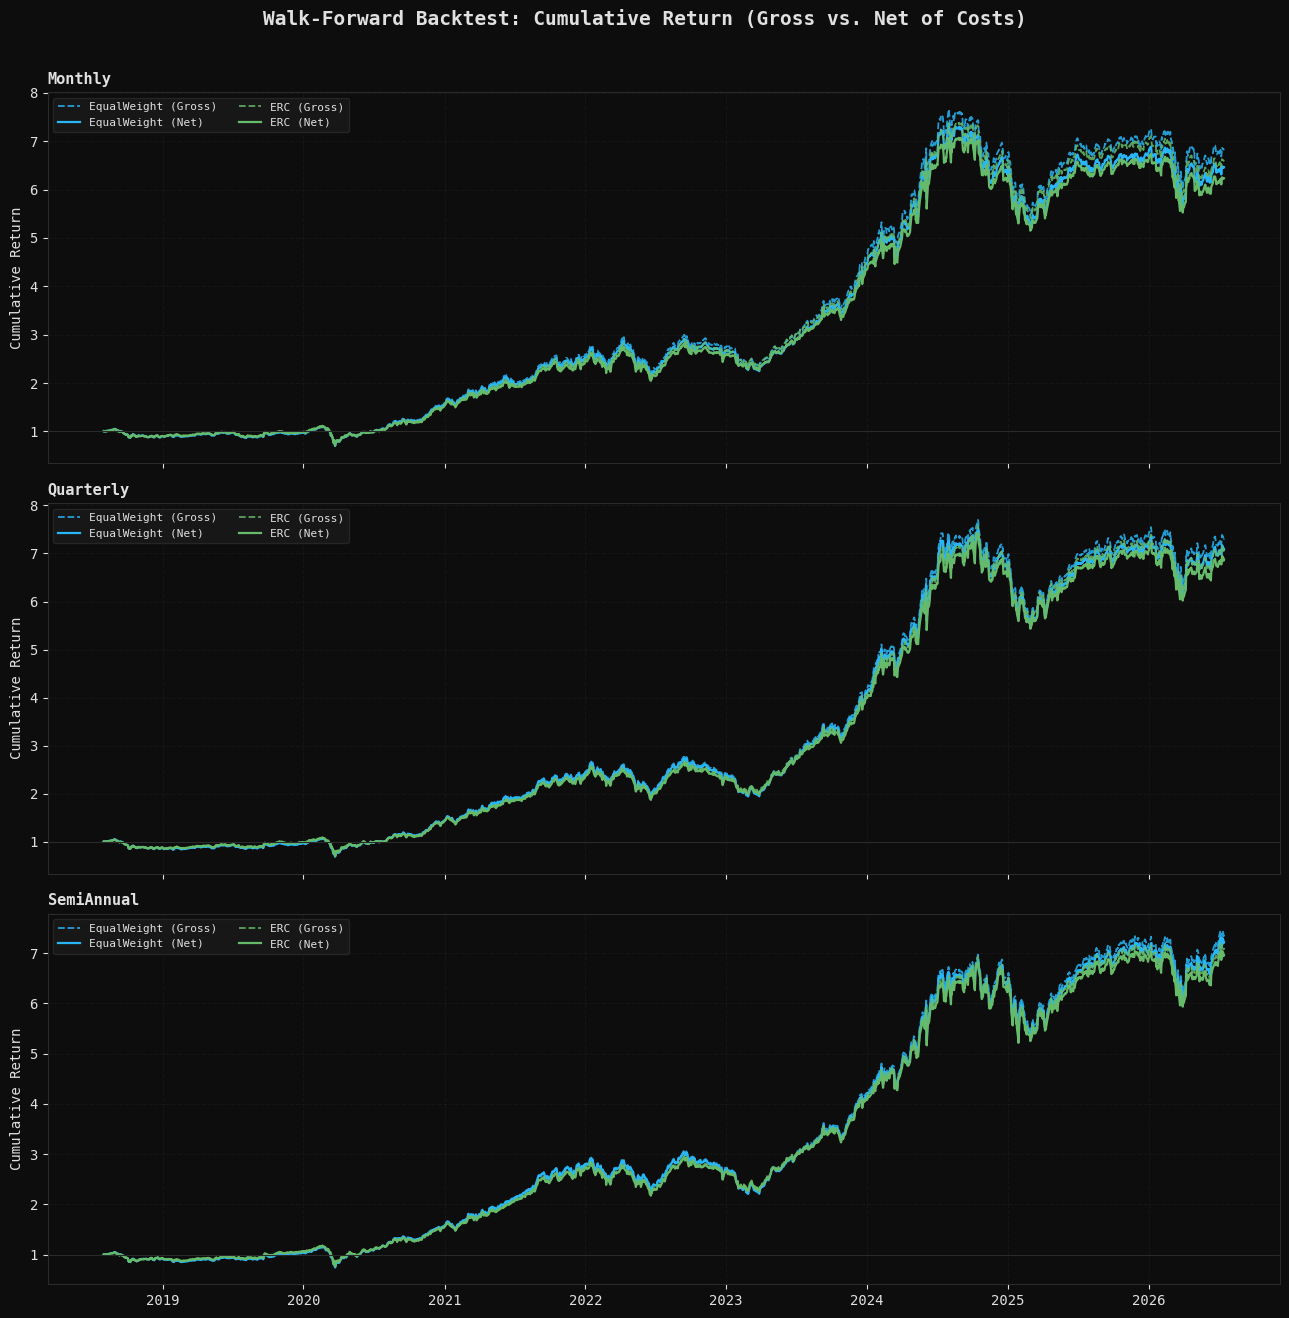

Saved -> .\output\04_cumulative_return_gross_vs_net.png


In [9]:
fig, axes = plt.subplots(len(REBAL_FREQ_STEP), 1, figsize=(13, 13), sharex=True)

for ax, freq_name in zip(axes, REBAL_FREQ_STEP.keys()):
    for i, scheme in enumerate(WEIGHTING_SCHEMES):
        sub = cumulative_returns_df[
            (cumulative_returns_df['frequency'] == freq_name) &
            (cumulative_returns_df['weighting_scheme'] == scheme)
        ]
        ax.plot(sub['date'], sub['cumulative_gross_return'], color=COLORS[i * 2], linewidth=1.3,
                linestyle='--', label=f'{scheme} (Gross)', alpha=0.85)
        ax.plot(sub['date'], sub['cumulative_net_return'], color=COLORS[i * 2], linewidth=1.6,
                label=f'{scheme} (Net)')

    ax.axhline(1.0, color=GRID_COLOR, linewidth=0.8)
    ax.set_title(freq_name, fontsize=11, fontweight='bold', color=TEXT_COLOR, loc='left')
    ax.set_ylabel('Cumulative Return')
    ax.legend(fontsize=8, ncol=2, loc='upper left')
    ax.grid(True, alpha=0.3)

fig.suptitle('Walk-Forward Backtest: Cumulative Return (Gross vs. Net of Costs)',
             fontsize=14, fontweight='bold', color=TEXT_COLOR, y=1.01)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '04_cumulative_return_gross_vs_net.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')


Final cumulative returns range from 6.61× to 7.37× Gross (560.94% to 636.59%) and 6.23× to
7.22× Net (523.29% to 621.65%) across the six combinations, with Quarterly and Semi-Annual Equal Weight
producing the highest Gross and Net figures in this backtest.

### Turnover and Cost Drag Diagnostics

Two views: turnover (%) at each individual rebalance — already familiar from Notebook 03's Portfolio
Research section, but now tied directly to the actual cost deducted from realized returns — and the
cumulative cost drag, how much of the Gross return each combination gave up to transaction costs over
the full backtest.

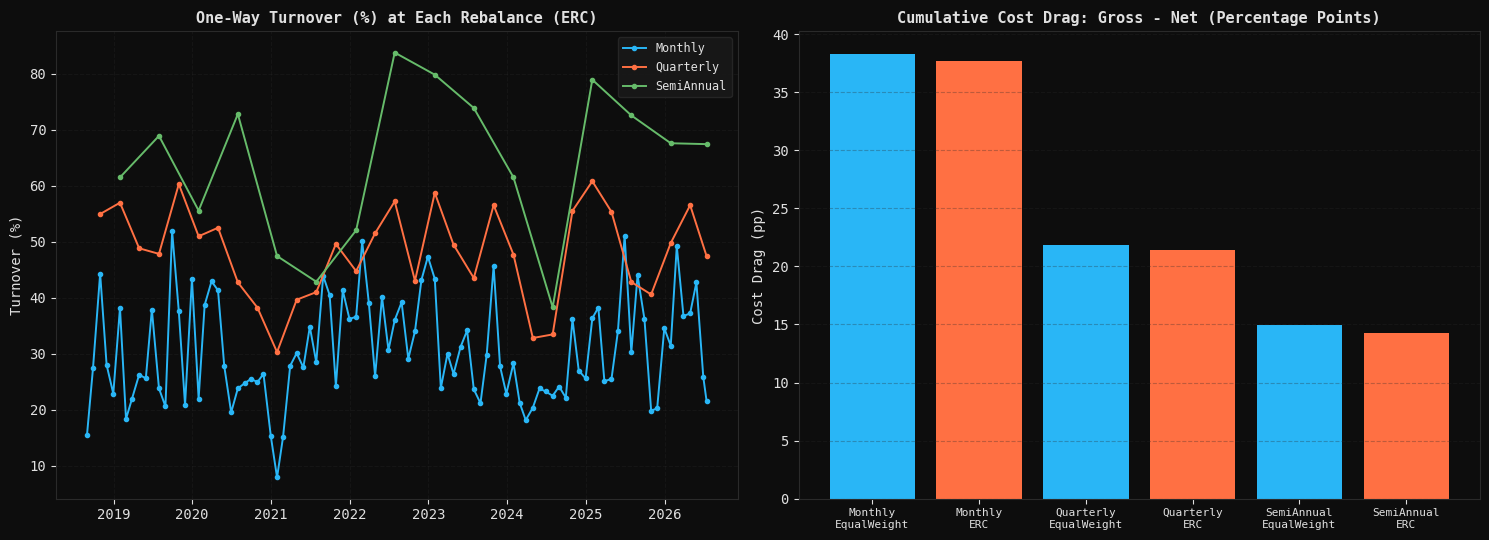

Saved -> .\output\04_turnover_and_cost_drag.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
for i, freq_name in enumerate(REBAL_FREQ_STEP.keys()):
    sub = turnover_cost_log[
        (turnover_cost_log['frequency'] == freq_name) &
        (turnover_cost_log['weighting_scheme'] == 'ERC')
    ]
    ax.plot(sub['rebalance_date'], sub['turnover_pct'], color=COLORS[i], linewidth=1.4,
            marker='o', markersize=3, label=freq_name)
ax.set_title('One-Way Turnover (%) at Each Rebalance (ERC)', fontsize=11, fontweight='bold',
             color=TEXT_COLOR)
ax.set_ylabel('Turnover (%)')
ax.legend(fontsize=8.5)
ax.grid(True, alpha=0.3)

ax = axes[1]
cost_drag_rows = []
for (freq_name, scheme), result in BACKTEST_RESULTS.items():
    cum_gross_final = (1.0 + result['gross_returns']).cumprod().iloc[-1]
    cum_net_final = (1.0 + result['net_returns']).cumprod().iloc[-1]
    cost_drag_pct = (cum_gross_final - cum_net_final) * 100.0
    cost_drag_rows.append({
        'frequency': freq_name, 'weighting_scheme': scheme, 'cumulative_cost_drag_pct': cost_drag_pct,
    })
cost_drag_df = pd.DataFrame(cost_drag_rows)

x_labels = [f'{f}\n{s}' for f, s in zip(cost_drag_df['frequency'], cost_drag_df['weighting_scheme'])]
bar_colors = [COLORS[0] if s == 'EqualWeight' else COLORS[1] for s in cost_drag_df['weighting_scheme']]
ax.bar(x_labels, cost_drag_df['cumulative_cost_drag_pct'], color=bar_colors)
ax.set_title('Cumulative Cost Drag: Gross - Net (Percentage Points)', fontsize=11,
             fontweight='bold', color=TEXT_COLOR)
ax.set_ylabel('Cost Drag (pp)')
ax.tick_params(axis='x', labelsize=8)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '04_turnover_and_cost_drag.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')


Cumulative cost drag (Gross minus Net, in percentage points) decreases monotonically as
rebalancing frequency lengthens: approximately 38.3pp (Monthly Equal Weight) and 37.7pp (Monthly ERC),
down to 21.8pp / 21.4pp (Quarterly) and 14.9pp / 14.3pp (Semi-Annual) — consistent with less frequent
rebalancing generating proportionally less turnover and therefore less cumulative cost, at the fixed
20 bps one-way-turnover cost assumption.

### Summary Table (Gross / Net / Cost Drag / Turnover, per Combination)

A walk-forward-backtest-level summary — total realized return, cost impact, average turnover — not
performance analytics. CAGR, Sharpe, Sortino, drawdown statistics, and benchmark-relative metrics
remain Notebook 05's responsibility.

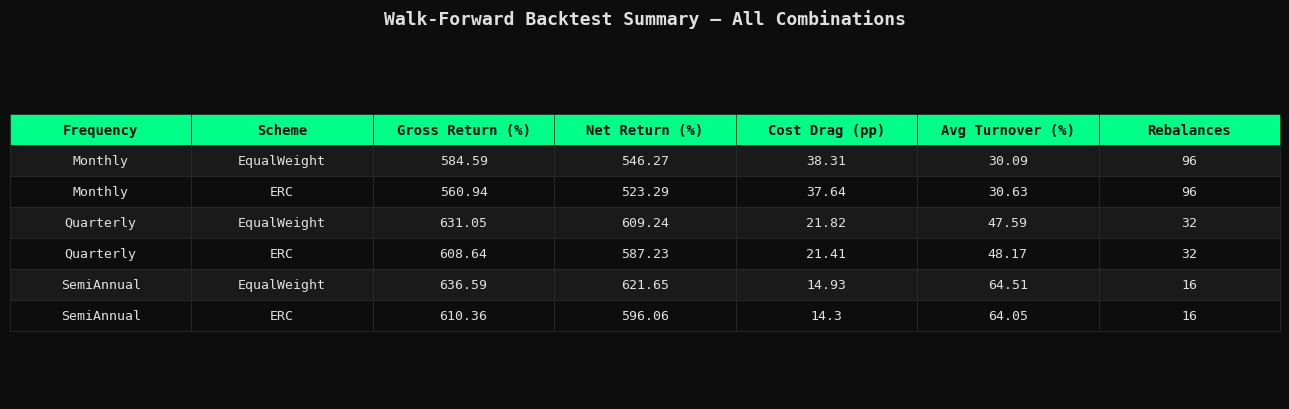

Saved -> .\output\04_backtest_summary_table.png


'.\\output\\04_backtest_summary_table.png'

In [11]:
def render_dark_table(df, title, filename, col_widths=None, figsize=None, header_color=ACCENT):
    n_rows, n_cols = df.shape
    fig_w = figsize[0] if figsize else max(9, 1.35 * n_cols)
    fig_h = figsize[1] if figsize else max(1.6, 0.42 * n_rows + 1.3)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')

    tbl = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center',
                   colWidths=col_widths)
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9.5)
    tbl.scale(1, 1.7)

    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor(GRID_COLOR)
        cell.set_linewidth(0.6)
        if row == 0:
            cell.set_facecolor(header_color)
            cell.set_text_props(weight='bold', color=DARK_BG, fontsize=10)
        else:
            cell.set_facecolor(PANEL_BG if (row - 1) % 2 == 0 else DARK_BG)
            cell.set_text_props(color=TEXT_COLOR)

    ax.set_title(title, fontsize=13, fontweight='bold', color=TEXT_COLOR, pad=16)
    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
    plt.show()
    print(f'Saved -> {path}')
    return path


summary_rows = []
for (freq_name, scheme), result in BACKTEST_RESULTS.items():
    cum_gross_final = (1.0 + result['gross_returns']).cumprod().iloc[-1]
    cum_net_final = (1.0 + result['net_returns']).cumprod().iloc[-1]
    avg_turnover = np.mean([t['turnover_pct'] for t in result['turnover_log']])
    summary_rows.append({
        'Frequency':        freq_name,
        'Scheme':           scheme,
        'Gross Return (%)': round((cum_gross_final - 1) * 100, 2),
        'Net Return (%)':   round((cum_net_final - 1) * 100, 2),
        'Cost Drag (pp)':   round((cum_gross_final - cum_net_final) * 100, 2),
        'Avg Turnover (%)': round(avg_turnover, 2),
        'Rebalances':       len(result['turnover_log']),
    })

summary_df = pd.DataFrame(summary_rows)
render_dark_table(summary_df, 'Walk-Forward Backtest Summary — All Combinations',
                   '04_backtest_summary_table.png', figsize=(13, 4.2))


### Save All Backtest Outputs to data/

Persists daily returns, cumulative returns, the turnover/cost log, engine diagnostics, and the
per-combination summary table, all consumed by Notebook 05.

In [12]:
backtest_daily_returns.to_csv(os.path.join(DATA_DIR, 'backtest_daily_returns.csv'), index=False)
cumulative_returns_df.to_csv(os.path.join(DATA_DIR, 'backtest_cumulative_returns.csv'), index=False)
turnover_cost_log.to_csv(os.path.join(DATA_DIR, 'backtest_turnover_cost_log.csv'), index=False)
diagnostics_df.to_csv(os.path.join(DATA_DIR, 'backtest_diagnostics.csv'), index=False)
summary_df.to_csv(os.path.join(DATA_DIR, 'backtest_summary.csv'), index=False)

print('Saved to data/:')
for f in ['backtest_daily_returns.csv', 'backtest_cumulative_returns.csv',
          'backtest_turnover_cost_log.csv', 'backtest_diagnostics.csv', 'backtest_summary.csv']:
    print(f'  {f}')

print()
print('=' * 60)
print('NOTEBOOK 04 -- COMPLETE')
print('=' * 60)
print(f'  Combinations backtested : {len(BACKTEST_RESULTS)} (3 frequencies x 2 weighting schemes)')
print(f'  Transaction cost        : {DEFAULT_COST_BPS} bps, one-way turnover basis')
print(f'  Total missing-return fills across all combos: '
      f'{sum(r["missing_return_fills"] for r in BACKTEST_RESULTS.values())}')
print()
print('  Charts in output/:')
for f in ['04_cumulative_return_gross_vs_net.png', '04_turnover_and_cost_drag.png',
          '04_backtest_summary_table.png']:
    print(f'    {f}')
print()
print('  Next -> Notebook 05: Portfolio Analytics (Sharpe/Sortino, benchmarks, drawdowns, '
      'sector analytics, cost sensitivity sweep)')


Saved to data/:
  backtest_daily_returns.csv
  backtest_cumulative_returns.csv
  backtest_turnover_cost_log.csv
  backtest_diagnostics.csv
  backtest_summary.csv

NOTEBOOK 04 -- COMPLETE
  Combinations backtested : 6 (3 frequencies x 2 weighting schemes)
  Transaction cost        : 20 bps, one-way turnover basis
  Total missing-return fills across all combos: 0

  Charts in output/:
    04_cumulative_return_gross_vs_net.png
    04_turnover_and_cost_drag.png
    04_backtest_summary_table.png

  Next -> Notebook 05: Portfolio Analytics (Sharpe/Sortino, benchmarks, drawdowns, sector analytics, cost sensitivity sweep)


---
## Results

- All six (frequency × weighting scheme) combinations produced 1,964 return days, with rebalance
  counts of 96 (Monthly), 32 (Quarterly), and 16 (Semi-Annual), and 0 missing-return fills across every
  combination.
- Date coverage matched the expected trading-day count exactly for all six combinations — no
  unexplained gaps.
- Final cumulative Gross / Net returns: Monthly EqualWeight 6.85× / 6.46×, Monthly ERC 6.61× / 6.23×,
  Quarterly EqualWeight 7.31× / 7.09×, Quarterly ERC 7.09× / 6.87×, Semi-Annual EqualWeight 7.37× /
  7.22×, Semi-Annual ERC 7.10× / 6.96×.
- Cumulative cost drag (Gross − Net, percentage points): Monthly 38.3 (EqualWeight) / 37.7 (ERC),
  Quarterly 21.8 / 21.4, Semi-Annual 14.9 / 14.3.

## Interpretation

Cost drag scales with rebalancing frequency as expected under a fixed one-way-turnover cost
assumption: Monthly rebalancing, which reconstitutes the portfolio far more often (96 rebalances versus
16 for Semi-Annual), accumulates roughly 2.6× the cost drag of Semi-Annual over the same backtest
window. Equal Weight and ERC show closely comparable Gross and Net outcomes within each frequency,
with ERC's Gross return slightly below Equal Weight's at every frequency in this backtest — consistent
with Notebook 03's finding that ERC's effective N is only marginally below Equal Weight's, so its
composition is close to, but not identical to, Equal Weight's. The zero missing-return-fill count and
exact date-coverage match indicate the return series can be taken at face value for Notebook 05's
performance-metric computations, with no data-quality caveat carried forward.

## Key Findings

The walk-forward engine passed all sanity checks (weight-sum integrity, contiguous date coverage, zero
missing-return fills) across all six combinations. Cost drag is the clearest frequency-driven signal in
this notebook: it more than doubles from Semi-Annual to Monthly rebalancing at the fixed 20 bps cost
assumption, while the underlying Gross return differences across frequencies and schemes are more
modest by comparison — indicating that, at this cost assumption, rebalancing frequency choice carries a
larger and more mechanically predictable Net-return consequence via cost drag than via the Gross return
differences between schemes.

## Limitations

- Transaction costs are modelled as one-way turnover × basis points only; no market-impact,
  bid-ask-spread, or slippage model is included beyond this single cost parameter.
- The Net-return figures above are computed only at the `DEFAULT_COST_BPS` (20 bps) assumption; Notebook
  05's cost-sensitivity sweep tests robustness to this assumption.
- Zero missing-return fills reflects a data panel that happened to have no gaps at the tickers actually
  held; this may not generalise beyond the specific universe and study window used here.

## Next Notebook

Notebook 05 (Portfolio Analytics) consumes `data/backtest_daily_returns.csv` and
`data/backtest_cumulative_returns.csv` to compute Sharpe, Sortino, Calmar, and drawdown statistics,
benchmark-relative metrics against NIFTY 50, the cost-sensitivity sweep, sector analytics, Rotation
Analysis, and Factor Attribution.